# Analyse der Offensivstrategien aller Teams

#### Pakete laden

In [2]:
import nflreadpy as nfl
import polars as pl
import numpy as np

### 4. Versuch ausspielen

#### Datengrundlage ziehen

In [3]:
fourth_downs = (
    nfl.load_pbp([2022,2023,2024, 2025])
    .filter(pl.col('down') == 4)
    .filter(
        (pl.col('play_type') =='pass') |
        (pl.col('play_type') =='run') | 
        (pl.col('play_type') =='np_play'))
    .select([
        'game_id', 'play_id', 'posteam', 'defteam', 'game_seconds_remaining', 
        'ydstogo', 'ydsnet', 'yardline_100',
        'fourth_down_converted', 'fourth_down_failed',
        'play_type', 'no_huddle', 'qb_dropback', 'qb_scramble',
        'pass_length', 'yards_after_catch', 'run_gap',
        'posteam_timeouts_remaining', 'defteam_timeouts_remaining',
        'score_differential',
        'no_score_prob', 'ep', 'epa', 'wp',
        'incomplete_pass', 'complete_pass', 'interception', 
        'rush_attempt', 'pass_attempt', 'sack', 'qb_hit', 'touchdown',
        'passer_player_id', 'passer_player_name', 
        'rusher_player_name', 'rusher_player_id',
        'home_coach', 'away_coach'
    ])
)


#### Zeitpunkte 

In [4]:
fourth_downs

game_id,play_id,posteam,defteam,game_seconds_remaining,ydstogo,ydsnet,yardline_100,fourth_down_converted,fourth_down_failed,play_type,no_huddle,qb_dropback,qb_scramble,pass_length,yards_after_catch,run_gap,posteam_timeouts_remaining,defteam_timeouts_remaining,score_differential,no_score_prob,ep,epa,wp,incomplete_pass,complete_pass,interception,rush_attempt,pass_attempt,sack,qb_hit,touchdown,passer_player_id,passer_player_name,rusher_player_name,rusher_player_id,home_coach,away_coach
str,f64,str,str,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,str,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str
"""2022_01_BAL_NYJ""",3419.0,"""NYJ""","""BAL""",452.0,1.0,62.0,28.0,1.0,0.0,"""pass""",0.0,1.0,0.0,"""short""",0.0,null,3.0,3.0,-21.0,0.104527,2.396708,2.097658,0.001759,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,"""00-0026158""","""J.Flacco""",null,null,"""Robert Saleh""","""John Harbaugh"""
"""2022_01_BAL_NYJ""",3551.0,"""NYJ""","""BAL""",317.0,3.0,62.0,14.0,1.0,0.0,"""pass""",0.0,1.0,0.0,"""short""",0.0,null,3.0,3.0,-21.0,0.058688,2.829552,2.139485,0.00229,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,"""00-0026158""","""J.Flacco""",null,null,"""Robert Saleh""","""John Harbaugh"""
"""2022_01_BAL_NYJ""",3647.0,"""NYJ""","""BAL""",262.0,6.0,62.0,6.0,0.0,1.0,"""pass""",0.0,1.0,0.0,"""short""",null,null,3.0,3.0,-21.0,0.060138,2.82976,-2.789325,0.005769,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,"""00-0026158""","""J.Flacco""",null,null,"""Robert Saleh""","""John Harbaugh"""
"""2022_01_BAL_NYJ""",4047.0,"""NYJ""","""BAL""",78.0,15.0,43.0,22.0,1.0,0.0,"""pass""",0.0,1.0,0.0,"""deep""",1.0,null,3.0,2.0,-21.0,0.177088,2.424586,3.545994,0.000711,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,"""00-0026158""","""J.Flacco""",null,null,"""Robert Saleh""","""John Harbaugh"""
"""2022_01_BUF_LA""",1358.0,"""LA""","""BUF""",2094.0,2.0,60.0,28.0,1.0,0.0,"""pass""",0.0,1.0,0.0,"""short""",5.0,null,3.0,3.0,-10.0,0.123353,2.1604,2.028536,0.276313,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,"""00-0026498""","""M.Stafford""",null,null,"""Sean McVay""","""Sean McDermott"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""2025_20_SF_SEA""",2802.0,"""SF""","""SEA""",952.0,3.0,7.0,62.0,0.0,1.0,"""pass""",0.0,1.0,0.0,"""deep""",null,null,3.0,1.0,-28.0,0.05949,-0.318751,-3.274082,0.000763,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,"""00-0037834""","""B.Purdy""",null,null,"""Mike Macdonald""","""Kyle Shanahan"""
"""2025_21_LA_SEA""",3590.0,"""LA""","""SEA""",496.0,1.0,84.0,26.0,1.0,0.0,"""run""",0.0,1.0,1.0,null,null,null,3.0,3.0,-4.0,0.074893,2.503086,1.796182,0.3945,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,null,null,"""M.Stafford""","""00-0026498""","""Mike Macdonald""","""Sean McVay"""
"""2025_21_LA_SEA""",3753.0,"""LA""","""SEA""",299.0,4.0,84.0,6.0,0.0,1.0,"""pass""",0.0,1.0,0.0,"""short""",null,null,3.0,3.0,-4.0,0.060583,2.874495,-2.833087,0.446136,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,"""00-0026498""","""M.Stafford""",null,null,"""Mike Macdonald""","""Sean McVay"""


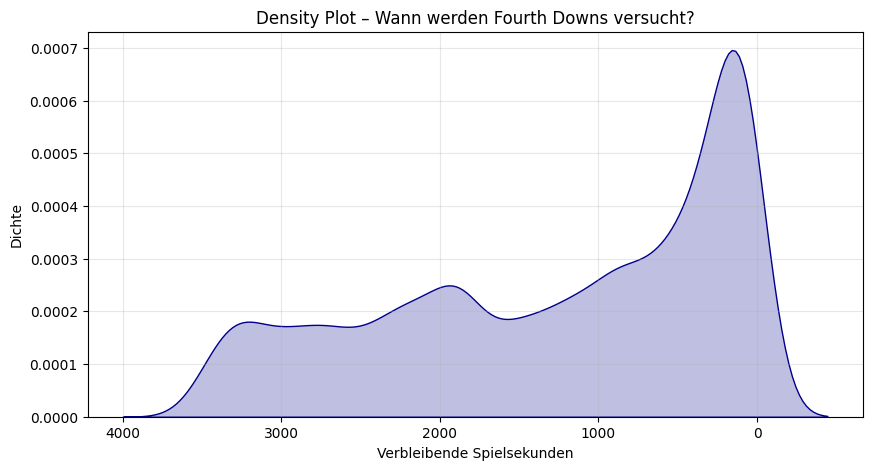

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.kdeplot(
    data=fourth_downs,
    x="game_seconds_remaining",
    fill=True,
    bw_adjust=0.7,
    color="darkblue"
)

plt.title("Density Plot – Wann werden Fourth Downs versucht?")
plt.xlabel("Verbleibende Spielsekunden")
plt.ylabel("Dichte")
plt.gca().invert_xaxis()  # 3600 → 0 (von Spielbeginn zu Spielende)

plt.grid(alpha=0.3)
plt.show()


In [6]:
truth_matrix = (
    fourth_downs
    .group_by(["ydstogo", "play_type"])
    .agg([
        pl.sum("fourth_down_converted").alias("converted"),
        pl.sum("fourth_down_failed").alias("failed"),
        pl.count().alias("total"),
        (pl.sum("fourth_down_converted") / pl.count()).alias("conversion_rate")
    ])
    .sort(["ydstogo", "play_type"])
)

truth_matrix



/tmp/ipykernel_1217/2585014336.py:7: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("total"),
/tmp/ipykernel_1217/2585014336.py:8: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  (pl.sum("fourth_down_converted") / pl.count()).alias("conversion_rate")


ydstogo,play_type,converted,failed,total,conversion_rate
f64,str,f64,f64,u32,f64
1.0,"""pass""",173.0,150.0,323,0.535604
1.0,"""run""",737.0,268.0,1006,0.732604
2.0,"""pass""",210.0,173.0,383,0.548303
2.0,"""run""",79.0,39.0,118,0.669492
3.0,"""pass""",160.0,154.0,314,0.509554
…,…,…,…,…,…
26.0,"""run""",0.0,1.0,1,0.0
27.0,"""pass""",1.0,4.0,5,0.2
28.0,"""pass""",0.0,2.0,2,0.0


<Axes: xlabel='ydstogo', ylabel='fourth_down_converted'>

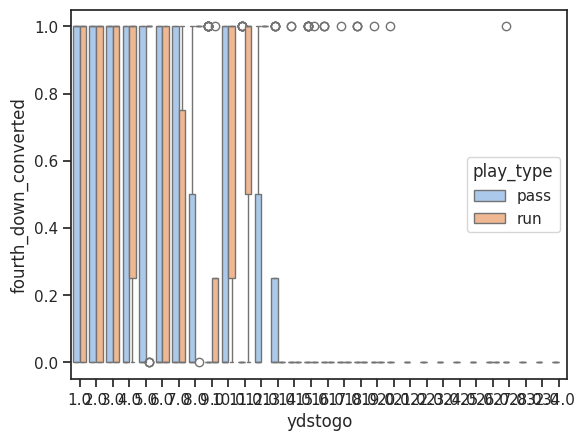

In [24]:
tm = fourth_downs.to_pandas()

sns.set_theme(style="ticks", palette="pastel")

# Draw a nested boxplot to show bills by day and time
sns.boxplot(x="ydstogo", y="fourth_down_converted",
            hue="play_type",
            data=tm)

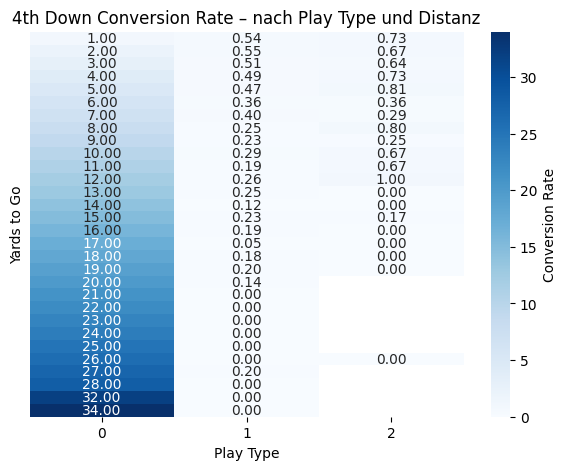

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

matrix = truth_matrix.pivot(
    values="conversion_rate",
    index="ydstogo",
    on="play_type"
)

plt.figure(figsize=(7, 5))
sns.heatmap(
    matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    cbar_kws={"label": "Conversion Rate"},
    yticklabels=False  # entfernt die erste Spalte (Yards-Labels)
)

plt.title("4th Down Conversion Rate – nach Play Type und Distanz")
plt.xlabel("Play Type")
plt.ylabel("Yards to Go")
plt.show()
